# Performance Comparison

In [ ]:
import sys
import fastf1
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.config import *
from src.load_save_data import *
from src.preprocess_data import *
from src.explore_data import *
from src.feature_engineering import *

# Case Study 1: Large Performance Gap

Deconstructing a 0.93-second gap at the 2025 Japanese Grand Prix (Q1)

During Q1 of the 2025 Japanese Grand Prix, a massive 0.93-second gap separated Fernando Alonso (1:28.337) and Lance Stroll (1:29.271). This section breaks down exactly where and how that time was extracted.

In [ ]:
TEAM = "Aston Martin"
GRAND_PRIX = "Japanese Grand Prix"
YEAR = 2025

In [ ]:
session = fastf1.get_session(YEAR, GRAND_PRIX, "Q")
session.load()

driver_1, driver_2 = get_drivers(session, TEAM)
segment = get_segment(session, driver_1, driver_2)
turns = get_turns(session)

try:
    lap_1, lap_2 = load_cache(YEAR, GRAND_PRIX, segment, driver_1, driver_2)
except Exception as e:
    print(f"Processed data for {YEAR} {GRAND_PRIX} {driver_1} and {driver_2} not found: {e}")

req         WARNING 	DEFAULT CACHE ENABLED! (99.92 MB) C:\Users\joseg\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '6', '44', '23', '87', '10', '55', '14', '30', '22', '27', '5', '31', '7', '18']



Processed data for 2025 Japanese Grand Prix ALO and STR found in cache.
Driver 1: ALO, Driver 2: STR, Segment: Q1


## Laps' Information

In [ ]:
print(f"=== Teammate Analysis for {YEAR} {GRAND_PRIX} ===")
print(f"Driver 1: {driver_1}, Lap Time: {lap_1['LapTime']}, Tyres: {lap_1['TyreCompound']}, Tyre Age: {lap_1['TyreAge']}")
print(f"Driver 2: {driver_2}, Lap Time: {lap_2['LapTime']}, Tyres: {lap_2['TyreCompound']}, Tyre Age: {lap_2['TyreAge']}")

print(f"Time delta between {driver_1} and {driver_2}: {-(lap_1['LapTime'] - lap_2['LapTime']):.3f} seconds")

=== Teammate Analysis for 2025 Japanese Grand Prix ===
Driver 1: ALO, Lap Time: 88.337, Tyres: SOFT, Tyre Age: 2
Driver 2: STR, Lap Time: 89.271, Tyres: SOFT, Tyre Age: 2
Time delta between ALO and STR: 0.934 seconds


Despite both drivers running the exact same tyre compound and identical tyre age, a massive 0.93-second gap still remains!

## Time Delta Analysis 

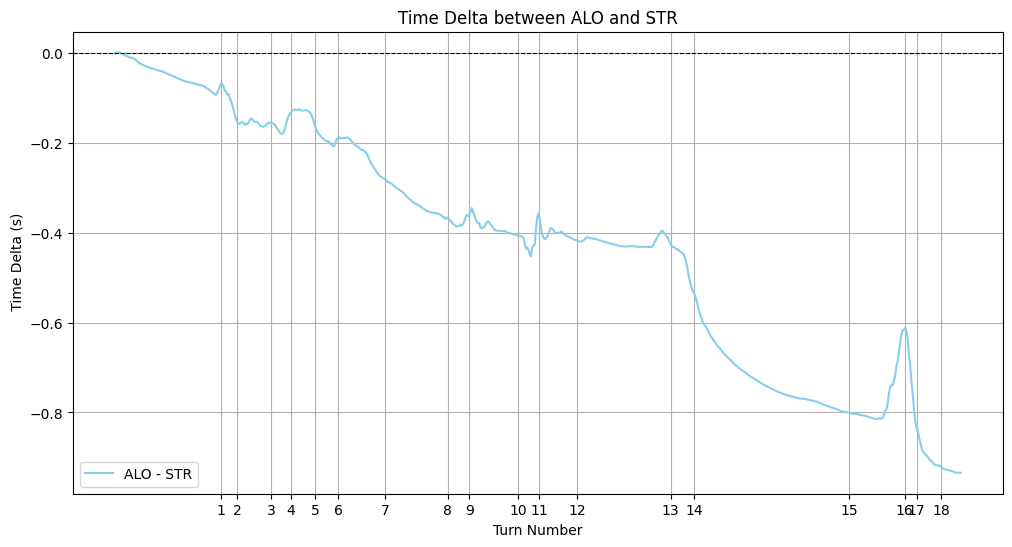

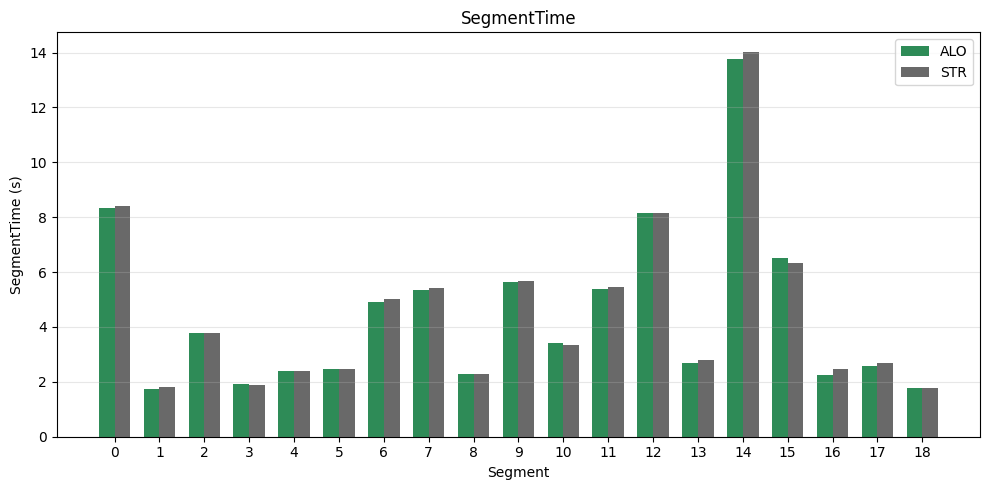

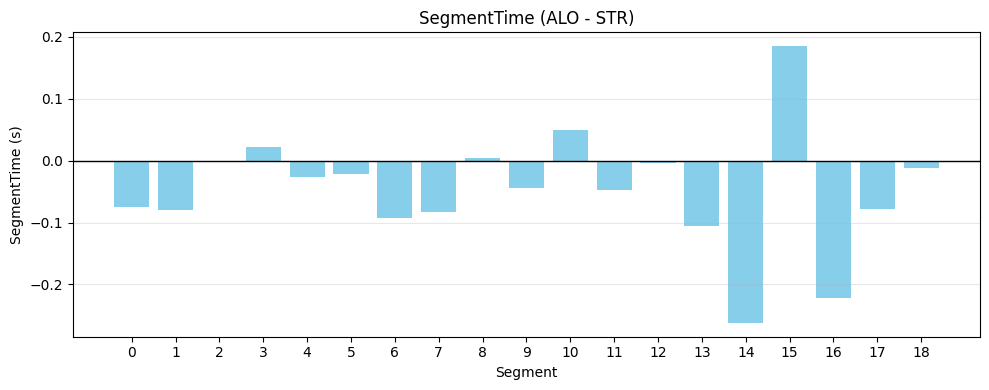

Segment time deltas between ALO and STR:
Start: -0.075 seconds
Turn 1: -0.080 seconds
Turn 2: -0.001 seconds
Turn 3: 0.022 seconds
Turn 4: -0.026 seconds
Turn 5: -0.022 seconds
Turn 6: -0.093 seconds
Turn 7: -0.083 seconds
Turn 8: 0.004 seconds
Turn 9: -0.044 seconds
Turn 10: 0.050 seconds
Turn 11: -0.047 seconds
Turn 12: -0.003 seconds
Turn 13: -0.106 seconds
Turn 14: -0.262 seconds
Turn 15: 0.185 seconds
Turn 16: -0.222 seconds
Turn 17: -0.078 seconds
Turn 18: -0.011 seconds


In [ ]:
plot_variable_delta(lap_1, lap_2, "Time", turns, y_unit="s")

barplot_feature_comparison(lap_1, lap_2, "SegmentTimes", "SegmentTime", y_unit="s")
barplot_feature_delta(lap_1, lap_2, "SegmentTimes", "SegmentTime", y_unit="s")

segment_time_deltas = lap_1["Segments"]["SegmentTime"] - lap_2["Segments"]["SegmentTime"]

print(f"Segment time deltas between {driver_1} and {driver_2}:")
for turn, delta in enumerate(segment_time_deltas):
    if turn != 0:
        print(f"Turn {turn}: {delta:.3f} seconds")
    else:
        print(f"Start: {delta:.3f} seconds")

In the first sector, Alonso demonstrates consistent and cumulative time gains. Because these corners naturally flow into one another, carrying momentum through this sequence is critical. Alonso manages to string these linked corners together seamlessly, compounding his speed advantage to build a solid early lead. Moving further into the lap, Turn 13 stands out as a distinct braking event where he secures a strong, isolated gain of 0.106 seconds, setting the stage for the most complex part of the track.

The undisputed highlight of this analysis is the high-volatility zone spanning Turns 14 through 16, where the time delta fluctuates wildly. The sequence begins at Turn 14, where Alonso extracts a massive 0.262-second advantage over Stroll. However, the dynamic shifts dramatically immediately after. At Turn 15, Stroll recovers a tremendous amount of ground, causing Alonso to drop 0.185 seconds in this single micro-sector. This sharp swing is clearly visible as a steep upward spike near the end of the delta line graph. Yet, Alonso retaliates just as quickly at Turn 16, crushing the sector time once again by pulling another 0.222 seconds ahead.

This absolute rollercoaster in the time delta strongly points to drastically different driving lines and overall approaches to this complex. The initial hypothesis is that we are witnessing a deliberate strategic compromise. It appears highly likely that Alonso intentionally sacrifices his minimum speed and overall time through the 14 and 15 sequence to guarantee superior car positioning and a perfectly optimized braking phase for Turn 16. By doing so, he establishes a much stronger platform for traction, maximizing his exit speed onto the ensuing straight and turning a short-term loss into a massive overall gain.

## Turns 1 to 12

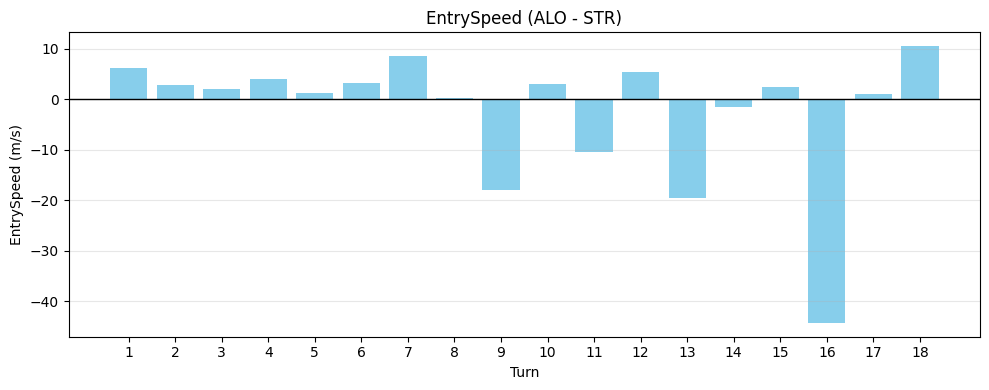

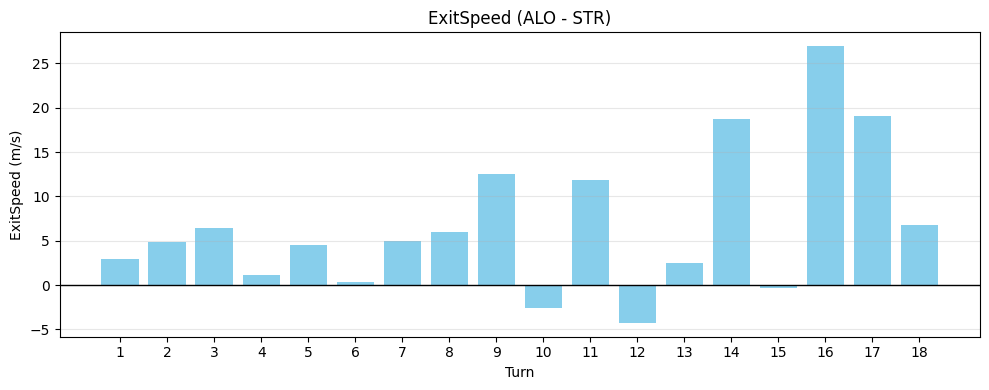

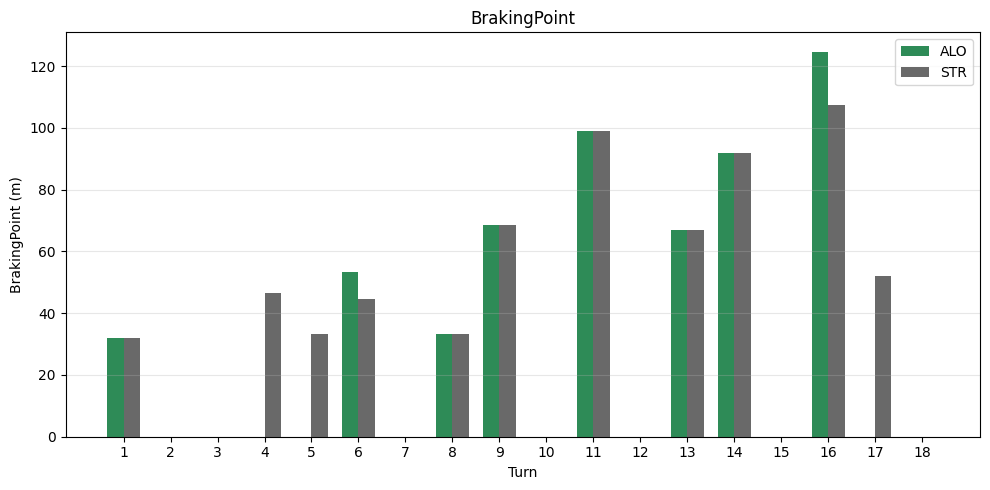

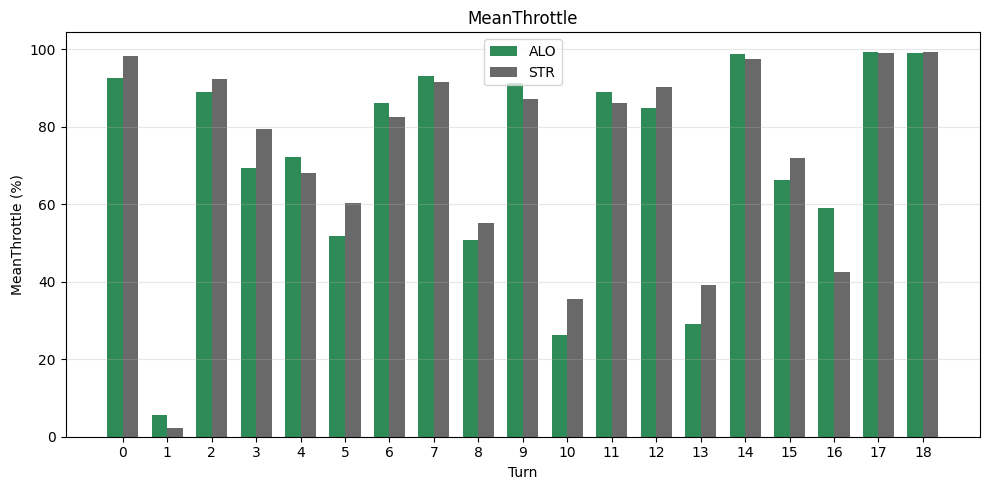

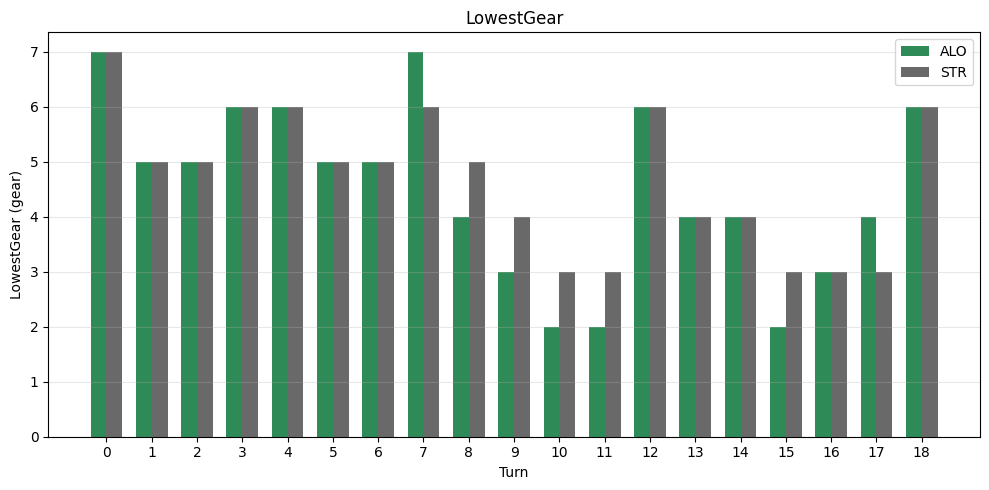

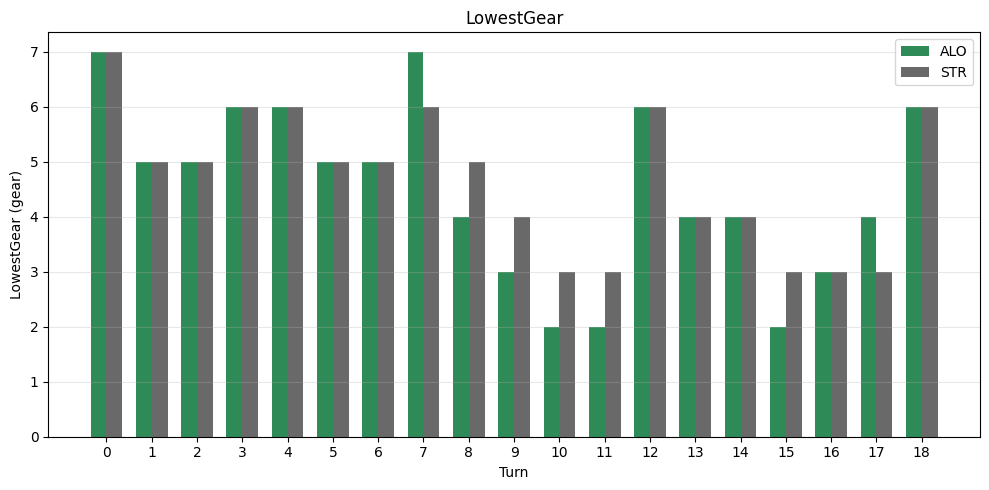

In [ ]:
barplot_feature_delta(lap_1, lap_2, "SpeedMetrics", "EntrySpeed", "m/s")
barplot_feature_delta(lap_1, lap_2, "SpeedMetrics", "ExitSpeed", "m/s")
barplot_feature_comparison(lap_1, lap_2, "BrakingZones", "BrakingPoint", y_unit="m")
barplot_feature_comparison(lap_1, lap_2, "ThrottleSegments", "MeanThrottle", y_unit="%")
barplot_feature_comparison(lap_1, lap_2, "GearShifts", "LowestGear", y_unit="gear")

At Turn 1, the telemetry shows identical braking points for both drivers at 31.9 meters. The time delta is generated during the brake release and corner entry phase. Alonso carries significantly more speed into the apex, registering an entry speed of 316.8 km/h compared to Stroll's 310.6 km/h. By maintaining a higher minimum speed without compromising his line, Alonso achieves a superior exit speed of 218.8 km/h against Stroll's 215.9 km/h.

The sequence through Turns 6 and 7 highlights a clear difference in momentum transfer. Alonso opts for an earlier braking point at Turn 6, hitting the brakes at 53.2 meters while Stroll brakes at 44.6 meters. Settling the car earlier allows Alonso to apply the throttle more aggressively. He records a mean throttle of 86.0% in Turn 6 and 93.0% in Turn 7, outperforming Stroll's 82.5% and 91.6%. This smoother weight transfer translates into a higher exit speed at Turn 7, with Alonso reaching 263.9 km/h compared to Stroll's 259.0 km/h.

Turn 9 provides a textbook execution of the "slow in, fast out" approach. Alonso shifts down to 3rd gear, whereas Stroll attempts to carry 4th gear through the corner. Consequently, Alonso's entry speed drops to 222.5 km/h, well below Stroll's 240.5 km/h. The lower gear provides better rotation, enabling Alonso to commit to the throttle earlier with a mean throttle of 91.3% versus 87.0%. The payoff is a clear exit speed advantage, as Alonso exits at 156.7 km/h against Stroll's 144.2 km/h.

The telemetry at Turn 10 exposes a difference in car fluidity. Stroll registers a 99.0-meter braking zone, relying on the pedal to keep the car on the racing line. Alonso does not use the brakes, relying entirely on a lift to navigate the section. Stroll's mean throttle is higher in this segment (35.4% compared to Alonso's 26.2%), but this is a reactive measure to recover the inertia lost during his unnecessary braking phase.

The telemetry at Turn 11 mirrors the strategy applied at Turn 9. Alonso aggressively downshifts to 2nd gear, while Stroll stays in 3rd. The pattern is identical: Alonso sacrifices entry speed, entering at 157.5 km/h compared to Stroll's 167.9 km/h, to secure a significantly higher exit speed of 128.0 km/h against his teammate's 116.1 km/h.

## Turns 13 to 18

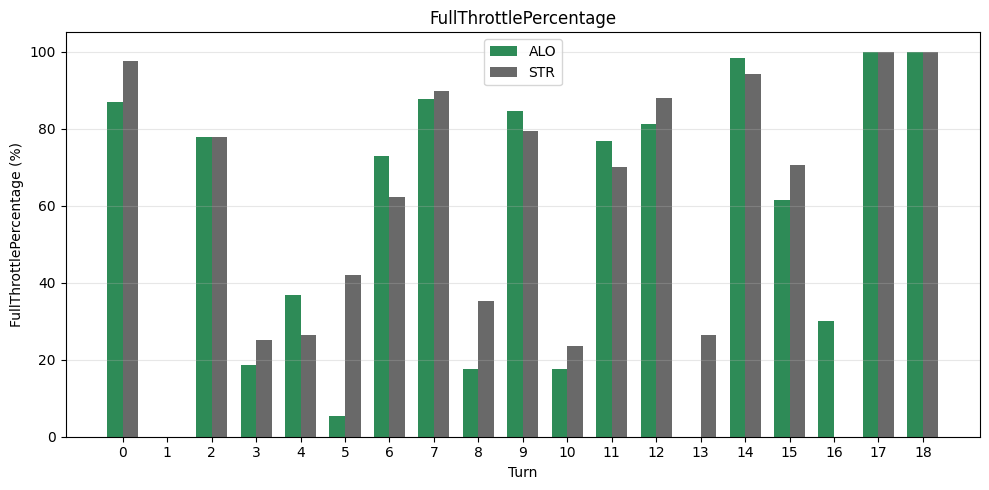

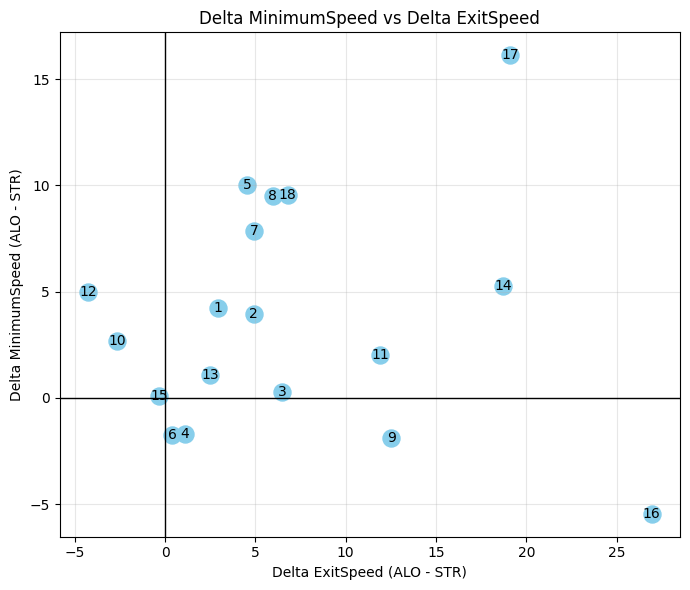

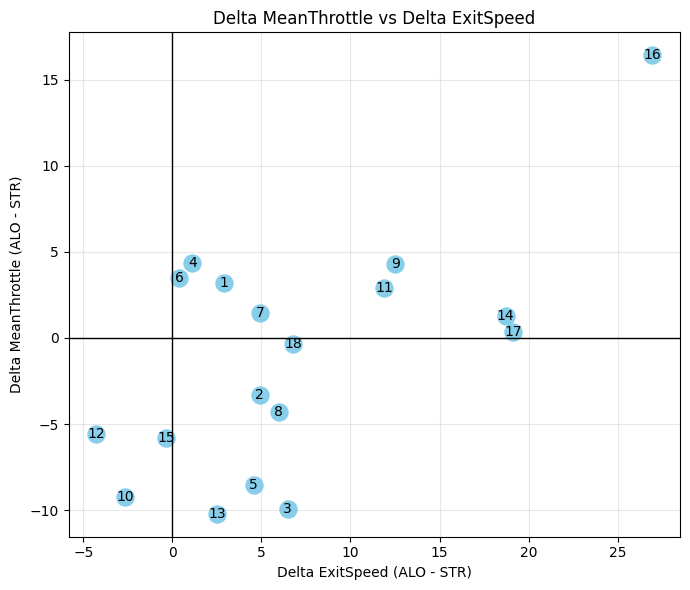

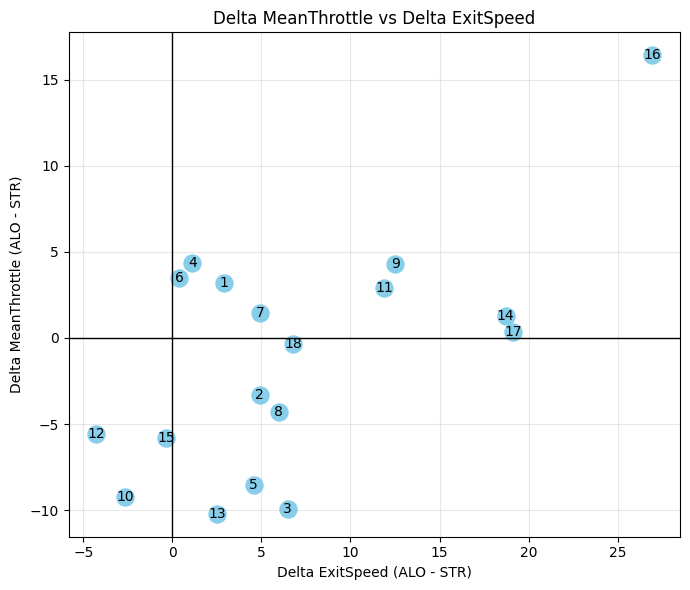

In [7]:
barplot_feature_comparison(lap_1, lap_2, "ThrottleSegments", "FullThrottlePercentage", y_unit="%")
scatterplot_features_relationship(lap_1,lap_2, "SpeedMetrics","ExitSpeed","SpeedMetrics","MinimumSpeed")
scatterplot_features_relationship(lap_1,lap_2, "SpeedMetrics","ExitSpeed","ThrottleSegments","MeanThrottle")

The data at Turn 13 reveals a classic telemetry trap regarding entry speed. Stroll commits the car to the corner at 296.1 km/h, while Alonso enters at a slower 276.4 km/h. However, Stroll is forced to spend 1.27 seconds on the brake pedal to scrub off this excess speed. Alonso applies the brakes for only 0.97 seconds, completing the deceleration phase earlier and exiting the corner with a speed advantage of 230.3 km/h compared to Stroll's 227.8 km/h.

At Turn 14, Alonso secures a significant exit speed advantage, reaching 197.6 km/h against Stroll's 178.9 km/h by applying full throttle much earlier. Immediately following this, Turn 15 highlights a strategic sacrifice. Stroll attacks the corner with a mean throttle of 71.9%, whereas Alonso registers only 66.1%. While Stroll gains time in this specific micro-sector, this aggressive approach severely compromises his car positioning for the critical braking zone that follows.

Turn 16 is where the lap is definitively won, with the telemetry isolating the exact mechanics of the massive time delta. Alonso initiates his braking phase at 124.6 meters, while Stroll attempts a later braking point at 107.4 meters. Mechanically, Alonso downshifts to 2nd gear to induce rotation, while Stroll attempts to navigate the apex in 3rd gear. Because Stroll carries the wrong trajectory and gear, he struggles with traction, registering 0% full throttle application in this segment. Conversely, with his car stabilized and properly rotated, Alonso spends 30% of the corner at full throttle. This fundamental difference in corner preparation results in Alonso exiting at 128.7 km/h, while Stroll is restricted to 101.8 km/h.

The remainder of the sector demonstrates the physical cascading effect of that exit speed. Because Alonso exits Turn 16 with such a significant momentum advantage, he carries this inertia through the subsequent flat-out sections. By the exit of Turn 17, Alonso reaches 199.6 km/h compared to Stroll's 180.4 km/h. This speed delta of nearly 20 km/h, generated entirely by the optimal setup at Turn 16, is carried all the way to the finish line, ultimately sealing the final gap on the stopwatch.

## Case Study Conclusion

The aggregate telemetry analysis reveals that Alonso's nearly one-second advantage over Stroll is not built by risking later braking points throughout the circuit. Instead, the primary performance delta stems from a strict and intentional application of the "slow in, fast out" concept.

The Delta ExitSpeed vs Delta MinimumSpeed scatter plot visualizes this strategy. Critical corners such as Turn 9, Turn 11, and the Turn 16 hairpin appear distinctly isolated in the upper-left quadrant. This positioning proves that Alonso actively avoids carrying excessive speed into the mid-corner, intentionally sacrificing minimum speed compared to Stroll, with the sole objective of rotating the car as quickly as possible. The return on this sacrifice is a massive differential in exit speed, reaching a nearly 27 km/h advantage out of Turn 16.

The mechanics behind this exit speed are validated by the Delta ExitSpeed vs Delta MeanThrottle plot. The same corners dominate the upper-right quadrant, highlighting a strong correlation between car positioning and throttle application. By completing the rotation phase earlier, Alonso secures a stable platform that allows him to apply full throttle much sooner than his teammate. Stroll, by attempting to carry more speed through the entry and mid-corner phases, is left struggling with poor traction on the corner exit.

In conclusion, this first case study demonstrates that a performance gap of this magnitude tends to be concentrated in very specific areas of the track. The time difference is not accumulated marginally over every corner, but rather through highly impactful, localized maneuvers where proper trajectory preparation yields dominant time gains on the subsequent straights.

# Case Study 2: Small Performance Gap

Deconstructing a 0.015-second gap at the 2025 British Grand Prix (Q3)

During Q3 of the 2025 British Grand Prix, a tiny 0.015-second gap separated Oscar Piastri (1:24.995) and Lando Norris (1:25.010). This section breaks down exactly where and how that time was extracted.

In [ ]:
TEAM = "McLaren"
GRAND_PRIX = "British Grand Prix"
YEAR = 2025

In [ ]:
session = fastf1.get_session(YEAR, GRAND_PRIX, "Q")
session.load()

driver_1, driver_2 = get_drivers(session, TEAM)
segment = get_segment(session, driver_1, driver_2)
turns = get_turns(session)

try:
    lap_1, lap_2 = load_cache(YEAR, GRAND_PRIX, segment, driver_1, driver_2)
except Exception as e:
    print(f"Processed data for {YEAR} {GRAND_PRIX} {driver_1} and {driver_2} not found: {e}")

core           INFO 	Loading data for British Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '63', '44', '16', '12', '87', '14', '10', '55', '22', '6', '23', '31', '30', '5', '18', '27', '43']



Processed data for 2025 British Grand Prix PIA and NOR found in cache.
Driver 1: PIA, Driver 2: NOR, Segment: Q3


## Laps' Information

In [ ]:
print(f"=== Teammate Analysis for {YEAR} {GRAND_PRIX} ===")
print(f"Driver 1: {driver_1}, Lap Time: {lap_1['LapTime']}, Tyres: {lap_1['TyreCompound']}, Tyre Age: {lap_1['TyreAge']}")
print(f"Driver 2: {driver_2}, Lap Time: {lap_2['LapTime']}, Tyres: {lap_2['TyreCompound']}, Tyre Age: {lap_2['TyreAge']}")

print(f"Time delta between {driver_1} and {driver_2}: {-(lap_1['LapTime'] - lap_2['LapTime']):.3f} seconds")

=== Teammate Analysis for 2025 British Grand Prix ===
Driver 1: PIA, Lap Time: 84.995, Tyres: SOFT, Tyre Age: 2
Driver 2: NOR, Lap Time: 85.01, Tyres: SOFT, Tyre Age: 2
Time delta between PIA and NOR: 0.015 seconds


Both drivers were running the exact same tyre compound and identical tyre age, and despite having different setups and driving styles only a tiny 0.015-second gap separates them.

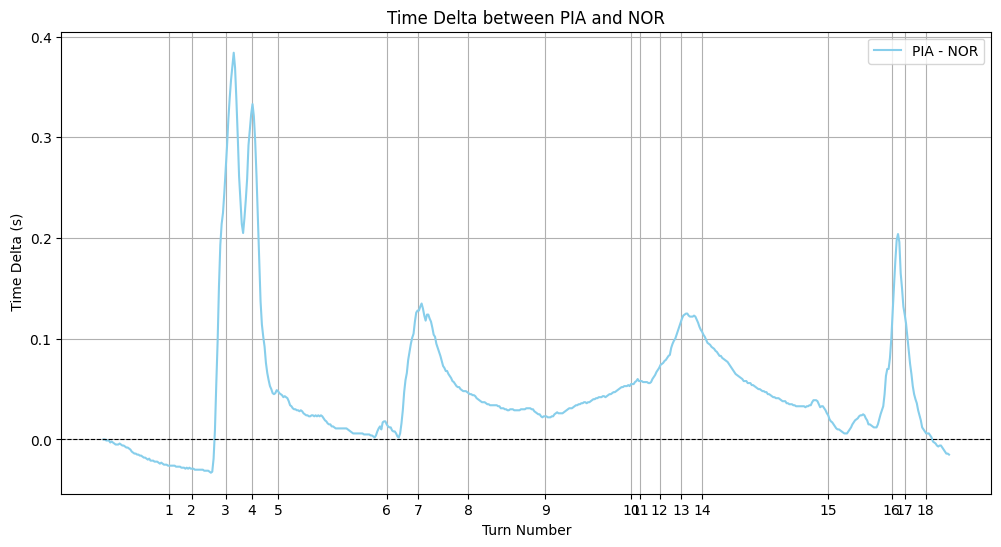

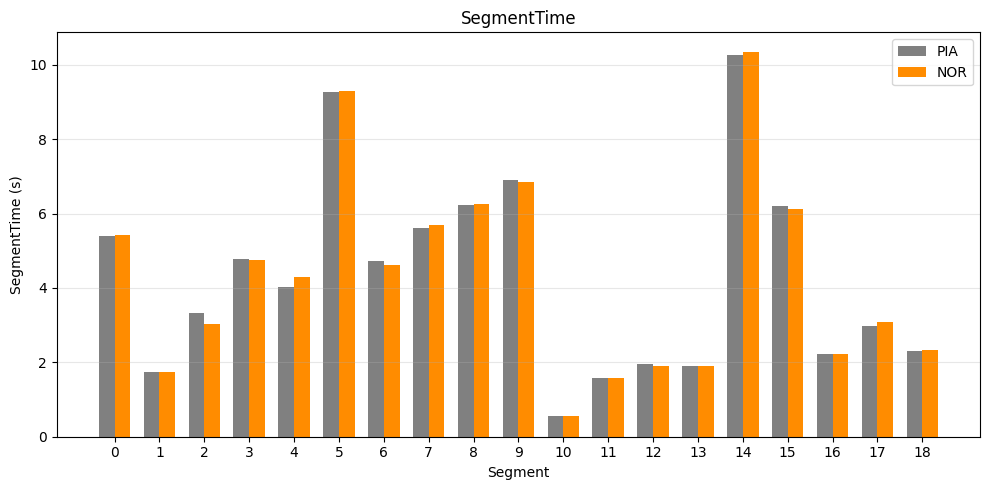

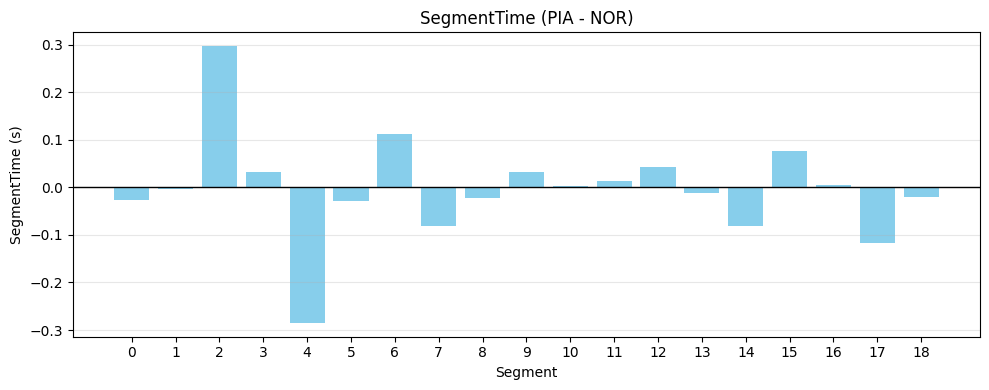

Segment time deltas between PIA and NOR:
Start: -0.026 seconds
Turn 1: -0.003 seconds
Turn 2: 0.297 seconds
Turn 3: 0.032 seconds
Turn 4: -0.285 seconds
Turn 5: -0.028 seconds
Turn 6: 0.113 seconds
Turn 7: -0.081 seconds
Turn 8: -0.023 seconds
Turn 9: 0.032 seconds
Turn 10: 0.003 seconds
Turn 11: 0.013 seconds
Turn 12: 0.042 seconds
Turn 13: -0.011 seconds
Turn 14: -0.081 seconds
Turn 15: 0.076 seconds
Turn 16: 0.005 seconds
Turn 17: -0.116 seconds
Turn 18: -0.021 seconds


In [ ]:
plot_variable_delta(lap_1, lap_2, "Time", turns, y_unit="s")

barplot_feature_comparison(lap_1, lap_2, "SegmentTimes", "SegmentTime", y_unit="s")
barplot_feature_delta(lap_1, lap_2, "SegmentTimes", "SegmentTime", y_unit="s")

segment_time_deltas = lap_1["SegmentTimes"]["SegmentTime"] - lap_2["SegmentTimes"]["SegmentTime"]

print(f"Segment time deltas between {driver_1} and {driver_2}:")
for turn, delta in enumerate(segment_time_deltas):
    if turn != 0:
        print(f"Turn {turn}: {delta:.3f} seconds")
    else:
        print(f"Start: {delta:.3f} seconds")

The lap begins with a relatively neutral entry through Turn 1, but Turn 2 immediately introduces a massive swing in performance. Norris extracts a massive 0.297 seconds over Piastri here, creating a significant and sharp upward spike in the delta graph. However, this advantage is almost entirely neutralized just as quickly. After a marginal 0.031-second gain for Norris in Turn 3, Piastri retaliates heavily in Turn 4, clawing back an impressive 0.284 seconds. Piastri carries this momentum slightly into Turn 5, edging out another 0.029 seconds. This extreme, high-volatility exchange suggests drastically different racing lines or a strategic compromise, showcasing how a near-identical overall lap time can be built on completely contrasting micro-sectors.

Moving further into the lap, the pendulum swings again, though with slightly less violence than the opening complex. Turn 6 sees Norris reclaim 0.112 seconds, indicating a stronger entry or better mid-corner rotation. Piastri immediately counters this in Turn 7, recovering 0.081 seconds, and manages to extend this localized advantage through Turn 8 by taking another 0.023 seconds. Unlike the massive fluctuations in the opening sequence, this sector represents a more rhythmic give-and-take. The drivers are trading smaller fractions of a second, likely optimizing different specific phases of this flowing corner sequence.

This middle section of the track is initially characterized by extreme marginality before a distinct shift in momentum. Turns 10 and 11 are practically identical, with Norris gaining a microscopic 0.004 and 0.014 seconds, respectively. Norris builds on this slightly in Turn 12, adding 0.043 seconds to his advantage. However, as the sequence transitions into the subsequent braking and traction zones, Piastri begins to shift the delta. After a negligible 0.011-second edge in Turn 13, Piastri secures a solid 0.080-second gain in Turn 14. This strongly points to superior braking stability or an earlier, cleaner throttle application that allows Piastri to carry more speed out of this specific complex.

The final sector perfectly encapsulates the fragmented micro-battle that defines this qualifying gap. Norris attacks Turn 15 effectively, securing a 0.077-second gain, before they match each other almost perfectly through Turn 16 (a neutral 0.005-second difference). The decisive late-lap counter-punch from Piastri arrives at Turn 17, where he sharply takes 0.116 seconds. This suggests Piastri highly optimized his exit trajectory leading onto the final straight, a momentum advantage he compounds with a final 0.022-second gain through Turn 18. 

## Turns 1 to 5

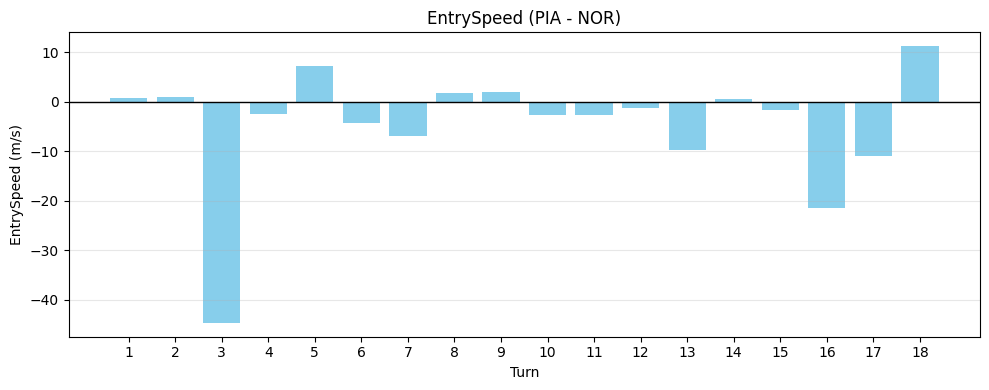

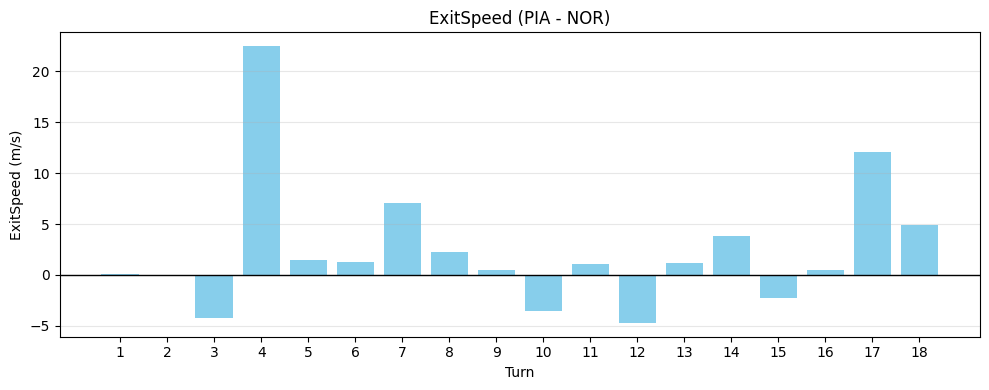

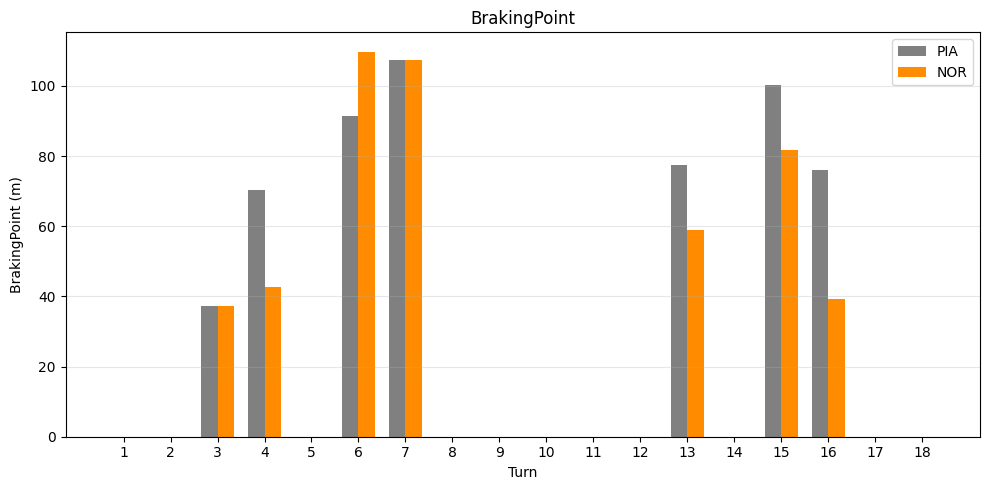

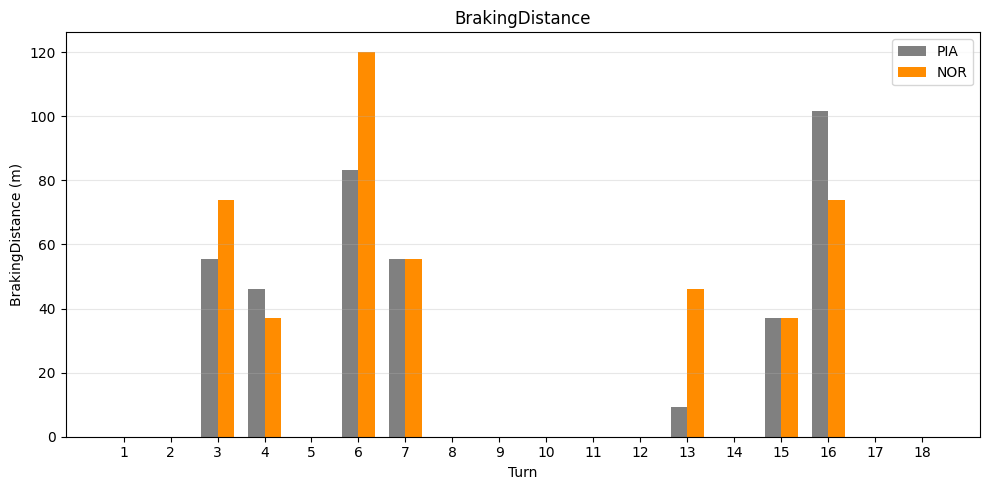

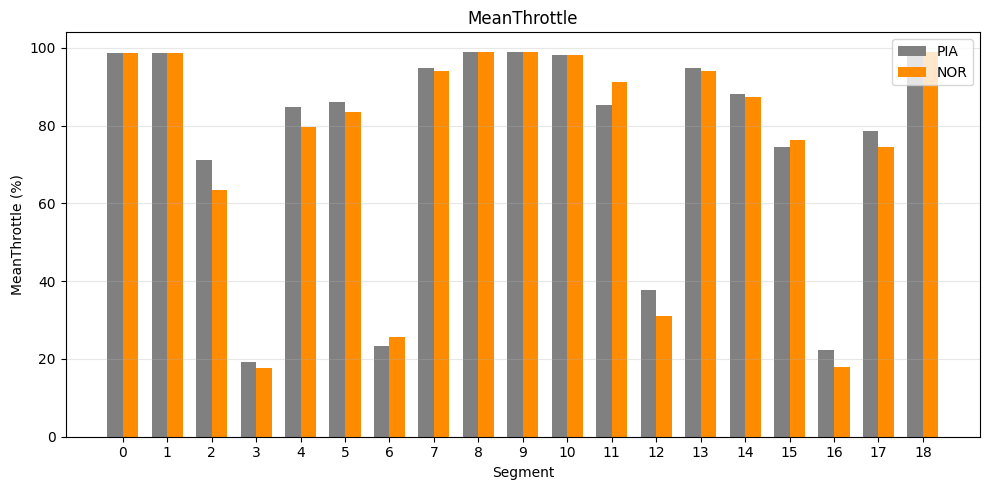

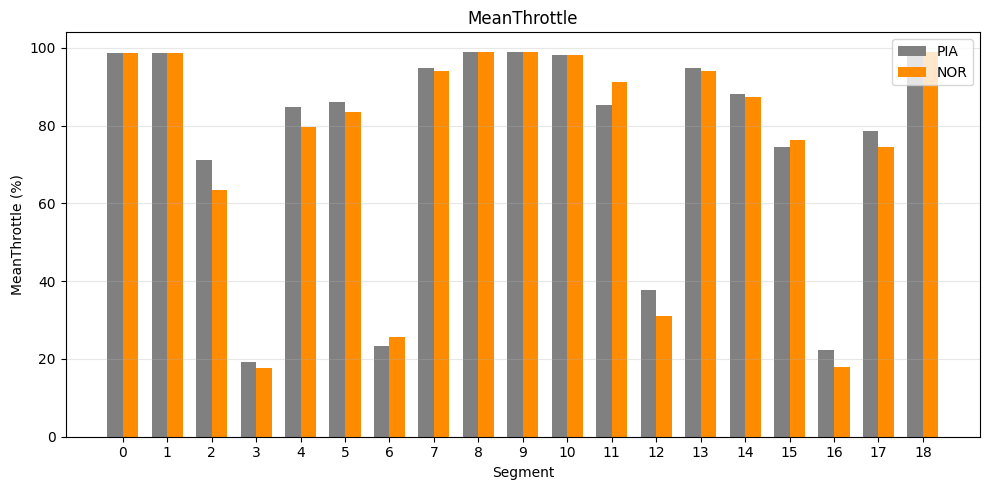

In [12]:
barplot_feature_delta(lap_1, lap_2, "SpeedMetrics", "EntrySpeed", "m/s")
barplot_feature_delta(lap_1, lap_2, "SpeedMetrics", "ExitSpeed", "m/s")
barplot_feature_comparison(lap_1, lap_2, "BrakingZones", "BrakingPoint", y_unit="m")
barplot_feature_comparison(lap_1, lap_2, "BrakingZones", "BrakingDistance", y_unit="m")
barplot_feature_comparison(lap_1, lap_2, "ThrottleSegments", "MeanThrottle", y_unit="%")

Through Turns 1 and 2, both drivers exhibit nearly identical profiles, taking the sequence flat-out in 8th gear without applying the brakes. Piastri and Norris register matching minimum speeds of 305.0 km/h in Turn 2. However, Piastri maintains slightly higher throttle commitment through the exit of Turn 2, averaging 71.1% mean throttle compared to Norris's 63.3%, setting up the approach speed into the first major braking zone.

Turn 3 highlights a major divergence in entry philosophy. Norris carries massive momentum into the corner, recording an entry speed of 291.1 km/h compared to Piastri's 246.5 km/h. To achieve this, Norris extends his braking zone considerably, covering 73.9 meters over 1.60 seconds compared to Piastri's 55.5 meters over 1.24 seconds. While this yields a higher minimum speed for Norris (130.3 km/h vs. 123.0 km/h), the delayed deceleration compromises his car balance through the apex.

The trade-off becomes evident immediately at Turn 4. Piastri initiates his braking phase much earlier at 70.4 meters, whereas Norris delays until 42.7 meters. By settling the chassis earlier, Piastri optimizes his corner geometry, enabling him to pick up the throttle sooner with a mean throttle of 84.8% against Norris's 79.7%. The result is a decisive exit speed advantage for Piastri, leaving Turn 4 at 139.4 km/h compared to Norris's 117.0 km/h.

Piastri carries this momentum cleanly into Turn 5, entering the corner at 199.3 km/h compared to Norris's 192.1 km/h. With the car properly platformed from the previous exit, Piastri sustains greater throttle commitment throughout the bend, recording a mean throttle of 86.2% and 86.3% full throttle application, outperforming Norris's 83.5% mean throttle. This allows Piastri to consolidate his exit advantage and carry higher speed onto the following section.

## Turns 6 to 8

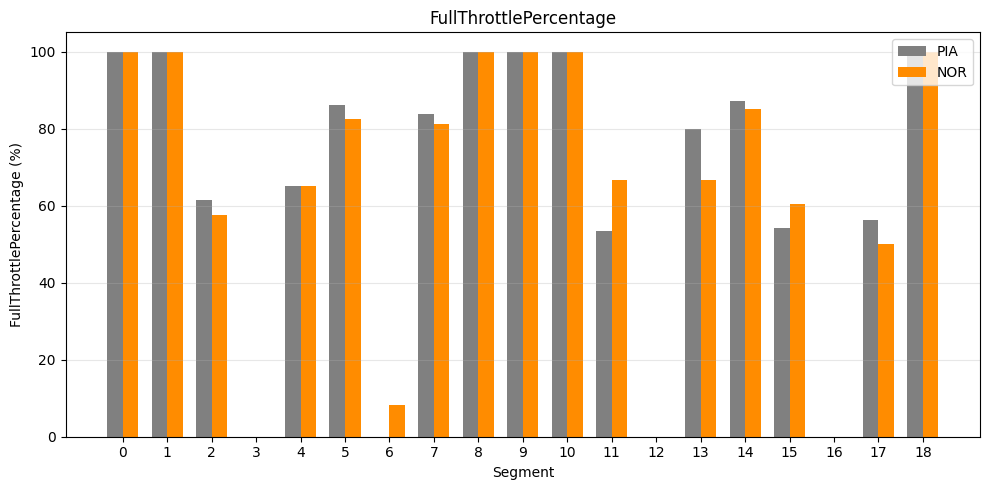

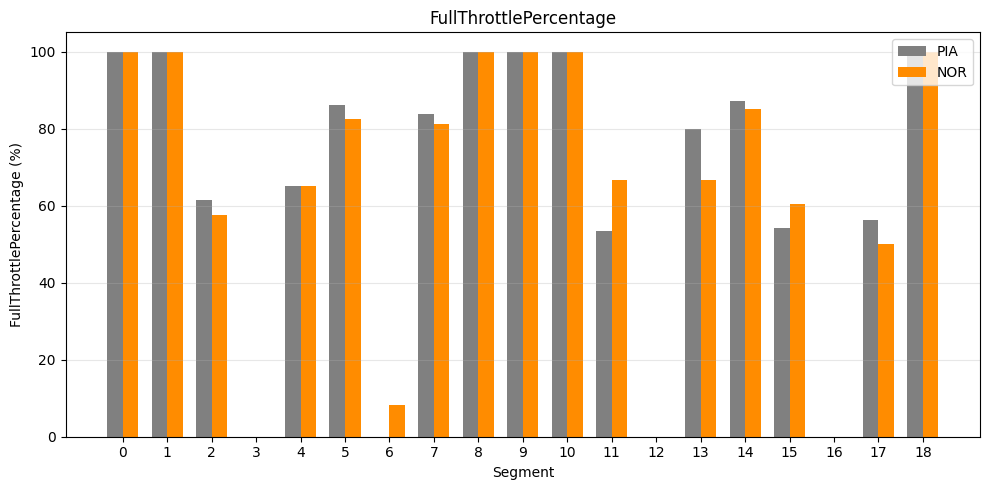

In [13]:
barplot_feature_comparison(lap_1, lap_2, "ThrottleSegments", "FullThrottlePercentage", y_unit="%")

At Turn 6, Norris attacks the corner entry aggressively, delaying his braking point to 109.8 meters compared to Piastri’s 91.3 meters. This requires Norris to cover a longer braking distance of 120.2 meters over 1.81 seconds, whereas Piastri decelerates over just 83.2 meters in 1.26 seconds. Norris's late-braking strategy yields an entry speed advantage of 258.7 km/h against Piastri's 254.4 km/h, earning Norris a 0.112-second segment gain. However, both drivers reach nearly identical minimum speeds through the apex (181.9 km/h for Piastri vs. 180.9 km/h for Norris), indicating that Norris's extra entry speed does not translate to mid-corner performance.

The dynamic reverses through Turn 7. Norris again carries higher initial momentum into the corner, entering at 144.8 km/h compared to Piastri’s 137.8 km/h, despite both drivers initiating braking at the exact same mark of 107.4 meters over an identical 55.5-meter distance. While Norris maintains a slightly higher minimum speed (120.3 km/h vs. 119.1 km/h), Piastri rotates the chassis more effectively at the apex. This enables Piastri to commit to the accelerator earlier and achieve 83.8% full throttle application compared to Norris’s 81.1%.

This earlier throttle pickup gives Piastri a decisive exit speed advantage out of Turn 7, leaving the corner at 163.8 km/h compared to Norris's 156.7 km/h. Piastri carries this extra 7.1 km/h directly into the high-speed sweep of Turn 8. Taking Turn 8 flat-out in 8th gear, Piastri maintains higher velocities throughout the bend—entering at 269.1 km/h and exiting at 288.3 km/h against Norris's 267.2 km/h entry and 286.1 km/h exit—allowing him to recover a total of 0.104 seconds across the Turn 7–8 sequence.

## Turns 9 to 14

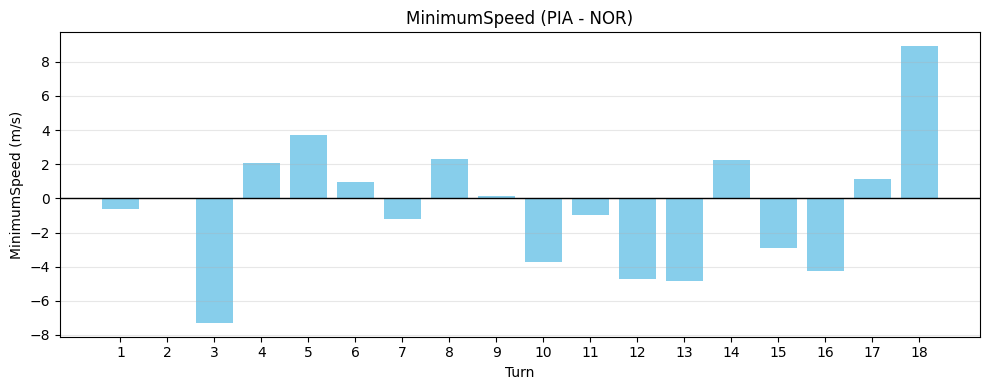

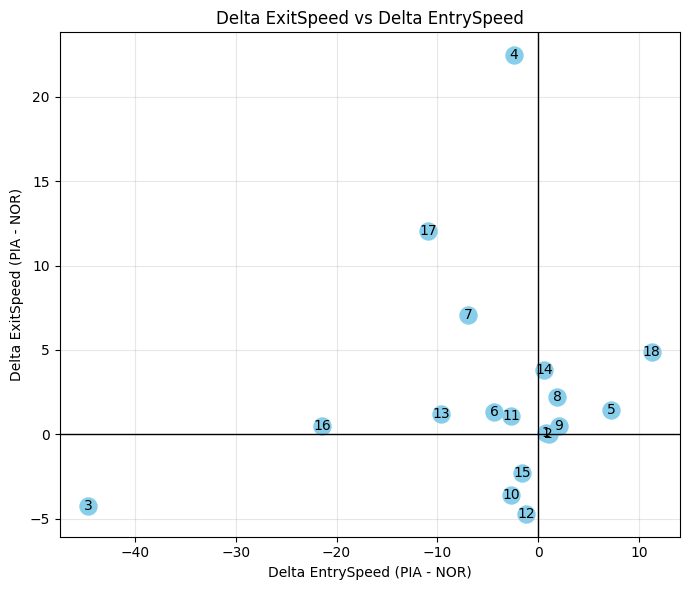

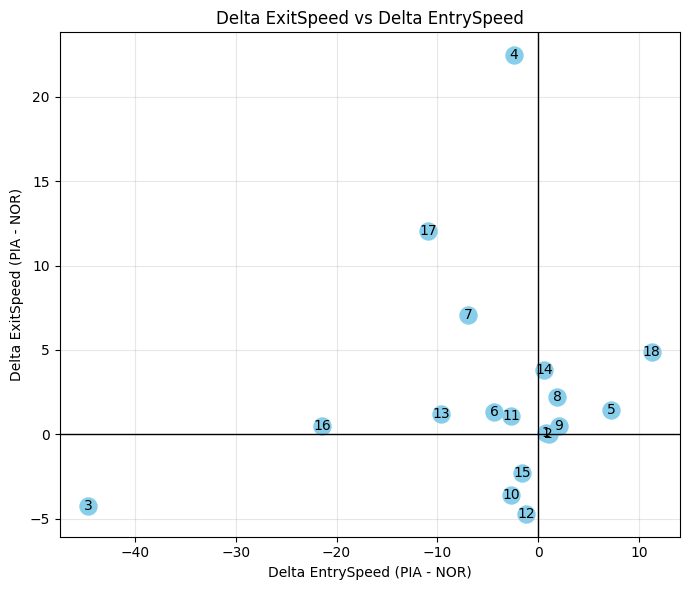

In [14]:
barplot_feature_delta(lap_1, lap_2, "SpeedMetrics", "MinimumSpeed", "m/s")
scatterplot_features_relationship(lap_1,lap_2, "SpeedMetrics","EntrySpeed","SpeedMetrics","ExitSpeed")

Through Turns 10 and 11, the lap remains extremely close. In Turn 10, taken flat-out in 8th gear with 100 percent full throttle for both drivers, Norris carries slightly higher speed across the segment, entering at 310.7 km/h and holding a minimum speed of 305.5 km/h compared to Piastri's 308.0 km/h entry and 301.8 km/h minimum. In Turn 11, Norris maintains greater throttle commitment, recording 91.2 percent mean throttle and 66.7 percent full throttle compared to Piastri's 85.3 percent mean throttle and 53.3 percent full throttle, yielding Norris marginal gains of 0.004 seconds and 0.014 seconds.

Norris extends this high-speed advantage into Turn 12. Both drivers downshift to 6th gear, but Norris maintains greater momentum throughout the curve, recording an entry of 297.0 km/h and a minimum speed of 276.9 km/h against Piastri's 295.8 km/h entry and 272.2 km/h minimum. Carrying an additional 4.7 km/h through the apex gives Norris a 0.043-second segment advantage before reaching the heavier deceleration zones.

The trend reverses at Turn 13. Norris carries higher entry speed (269.3 km/h vs 259.6 km/h) but over-commits, forcing him into a prolonged braking phase. Norris spends 0.67 seconds on the brakes covering 46.2 meters, whereas Piastri executes a brief 0.13-second tap over just 9.2 meters. Consequently, Piastri achieves a higher exit speed (239.2 km/h vs 238.0 km/h) and greater full throttle commitment (80.0 percent vs 66.7 percent), taking back 0.011 seconds.

Piastri consolidates this momentum through Turn 14. Setting up his braking phase earlier at 100.3 meters compared to Norris's 81.8 meters, Piastri secures a higher minimum speed (249.4 km/h vs 247.1 km/h). With the car settled earlier, Piastri applies full throttle over 87.2 percent of the segment versus Norris's 85.1 percent, launching out of Turn 14 at 270.1 km/h compared to Norris's 266.3 km/h. Carrying a 3.8 km/h exit advantage, Piastri claims a decisive 0.080-second gain to close out the complex.

## Turns 15 to 18

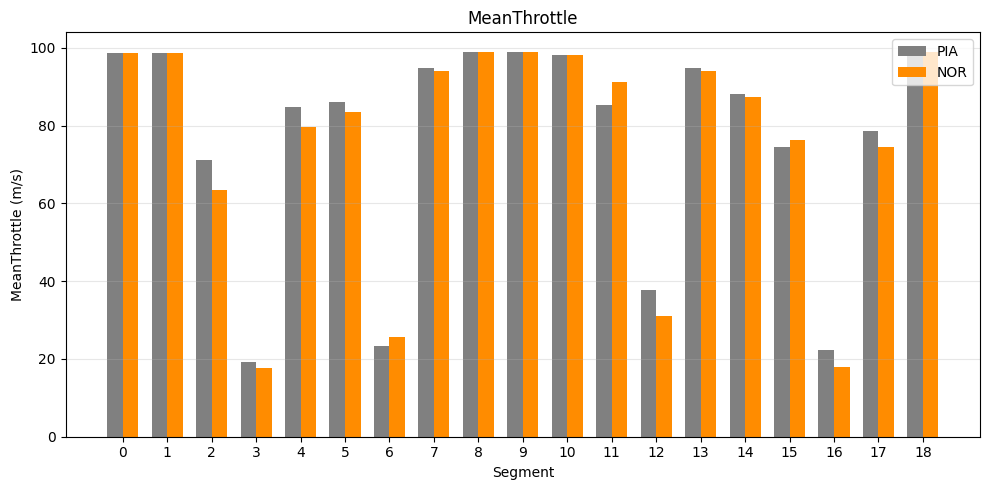

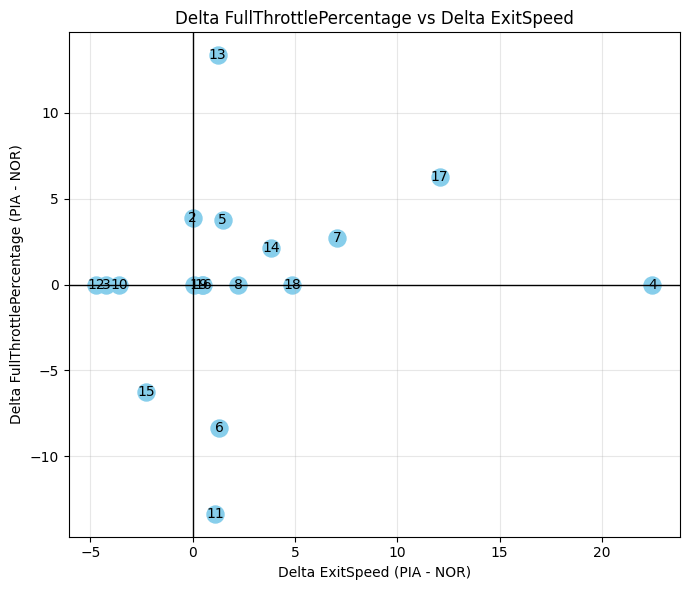

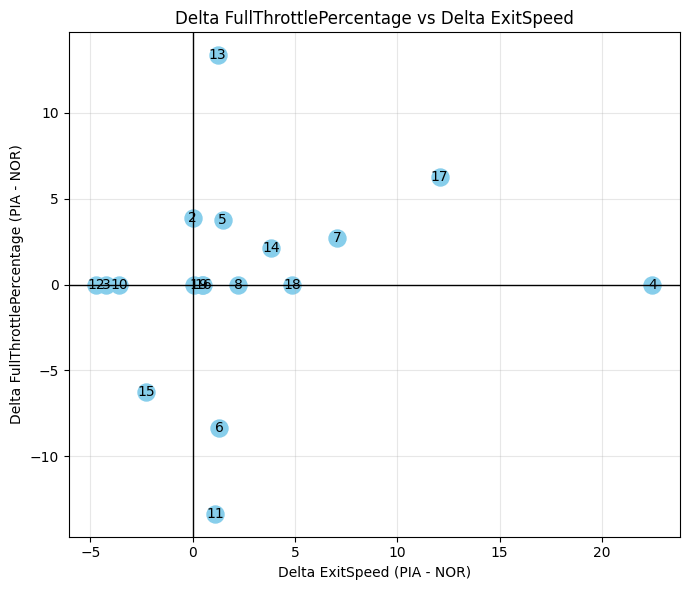

In [15]:
barplot_feature_comparison(lap_1, lap_2, "ThrottleSegments", "MeanThrottle", "m/s")
scatterplot_features_relationship(lap_1,lap_2, "SpeedMetrics","ExitSpeed","ThrottleSegments","FullThrottlePercentage")

At Turn 15, Norris attacks the entry with higher speed, entering at 285.3 km/h compared to Piastri 283.7 km/h. Norris maintains a higher minimum speed of 253.8 km/h versus Piastri 250.9 km/h and sustains greater throttle commitment, recording 76.4 percent mean throttle and 60.4 percent full throttle against Piastri 74.6 percent mean throttle and 54.2 percent full throttle. This enables Norris to exit Turn 15 at 252.6 km/h compared to Piastri 250.3 km/h, earning Norris a 0.077-second advantage.

Through Turn 16, Norris carries significantly more entry momentum at 286.0 km/h compared to Piastri 264.5 km/h by delaying his braking initiation to 39.2 meters versus Piastri 76.1 meters. Consequently, Piastri decelerates over a longer distance of 101.7 meters over 2.16 seconds, whereas Norris covers 73.9 meters over 1.78 seconds. While Norris holds a higher minimum speed through the apex at 115.3 km/h against Piastri 111.0 km/h, Piastri stabilizes the car effectively to match Norris on exit speed, leaving at 112.7 km/h compared to Norris 112.2 km/h, resulting in an essentially neutral 0.005-second delta.

Turn 17 serves as the decisive moment of the final sector. Piastri enters at 111.0 km/h and maintains a minimum speed of 111.2 km/h, whereas Norris enters at 121.9 km/h but suffers a sharper speed drop down to 110.1 km/h. Piastri achieves superior throttle application out of the corner, registering 78.5 percent mean throttle and 56.3 percent full throttle application compared to Norris 74.5 percent mean throttle and 50.0 percent full throttle. This grants Piastri a massive exit speed advantage of 156.3 km/h against Norris 144.2 km/h, allowing Piastri to claim a 0.116-second gain.

Piastri carries this extra 12.1 km/h directly into Turn 18, entering at 188.1 km/h compared to Norris 176.8 km/h. Piastri maintains higher velocities throughout the bend, holding a minimum speed of 192.4 km/h and an exit speed of 238.4 km/h compared to Norris 183.4 km/h minimum and 233.5 km/h exit, adding a final 0.022-second recovery to complete the lap.

## Case Study Conclusion

The aggregate telemetry analysis reveals that the razor-thin performance gap between Piastri and Norris is defined by two fundamentally opposing driving approaches rather than uniform speed differences across the lap. While Norris consistently seeks time gains by over-committing to corner entries and pushing braking markers to the absolute limit, Piastri achieves his performance through superior chassis stabilization, earlier traction application, and exit speed optimization.

The Delta EntrySpeed vs Delta ExitSpeed scatter plot clearly illustrates this fundamental trade-off. High-volatility complexes such as Turns 3–4, 13–14, and 17 feature prominently, showing Norris positioned high on entry speed but suffering relative to Piastri on exit velocity. Norris's aggressive entry approach forces longer deceleration windows and compromises car balance through the apex. In contrast, Piastri systematically moderates entry speeds to rotate the car earlier, converting that patience into decisive exit speed advantages, most notably out of Turn 4 and Turn 17.

The mechanics behind Piastri's exit advantage are further validated by the Delta ExitSpeed vs Delta FullThrottlePercentage plot. A strong positive correlation emerges in key acceleration zones, where Piastri's higher exit velocities directly align with significantly greater full-throttle commitment. By settling the platform earlier during the cornering phase, Piastri eliminates micro-corrections and applies full throttle much sooner than Norris, who is frequently left managing traction limitations caused by carrying excess entry momentum.

In conclusion, this second case study demonstrates that near-identical overall lap times can mask radically different driving dynamics. The battle between Piastri and Norris highlights how aggressive entry techniques and methodical corner preparation can balance out over a single lap, proving that micro-sector volatility is often the result of contrasting compromises between late-braking aggression and exit-traction efficiency.

# Conclusion

The combined findings from both case studies demonstrate that lap time in modern Formula 1 is overwhelmingly dictated by corner exit preparation and platform stabilization rather than late-braking aggression. Across both intra-team matchups, the telemetry consistently disproves the notion that ultimate performance is extracted by forcing speed into the entry phase of a corner. Instead, lap time is defined by how effectively a driver rotates the chassis to establish an early, stable platform for throttle application.

The contrast between the two scenarios reveals how these driving dynamics manifest across different performance margins. In the first case study, a substantial gap of nearly a second is generated when one driver strictly adheres to the "slow in, fast out" philosophy while the teammate repeatedly over-commits on entry, destroying exit speeds on key straights. In the second case study, a razor-thin overall margin hides high micro-sector volatility, proving that late-braking entry aggression and methodical exit preparation can temporarily offset each other across a single lap.

Ultimately, aggregate telemetry analysis underscores that driver capability cannot be judged by entry speeds or delayed braking markers alone. The single most decisive factor in extracting maximum car potential remains the discipline to prioritize vehicle rotation and exit traction, confirming that time in modern motorsport is rarely won on the way into the corner, but almost always on the way out.